Loading best model from: /home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/ppmi_multinit_bestparams/PPMI_subtyping_multinit_best.npz
Keys: ['theta_history', 'cog_history', 'beta_history', 'lse_history', 'assignment_history', 'beta_val', 'f_init', 'train_assignments', 'val_assignments', 'train_ids', 'val_ids', 'final_assignments', 'cluster_f', 'cluster_cog_a', 'cluster_cog_b', 'final_scalar_K', 'final_s', 'lambda_f', 'lambda_cog', 'lambda_scalar', 'lambda_jsd', 'lambda_beta', 'n_initializations', 'best_init_index', 'n_successful']

Best Model Final LSE: 714.838346
Number of initializations: 100
Best initialization index: 0

Parameters:
  lambda_f: 0.6
  lambda_cog: 0.2
  lambda_scalar: 1.1
  lambda_jsd: 0.4
  lambda_beta: 0.01


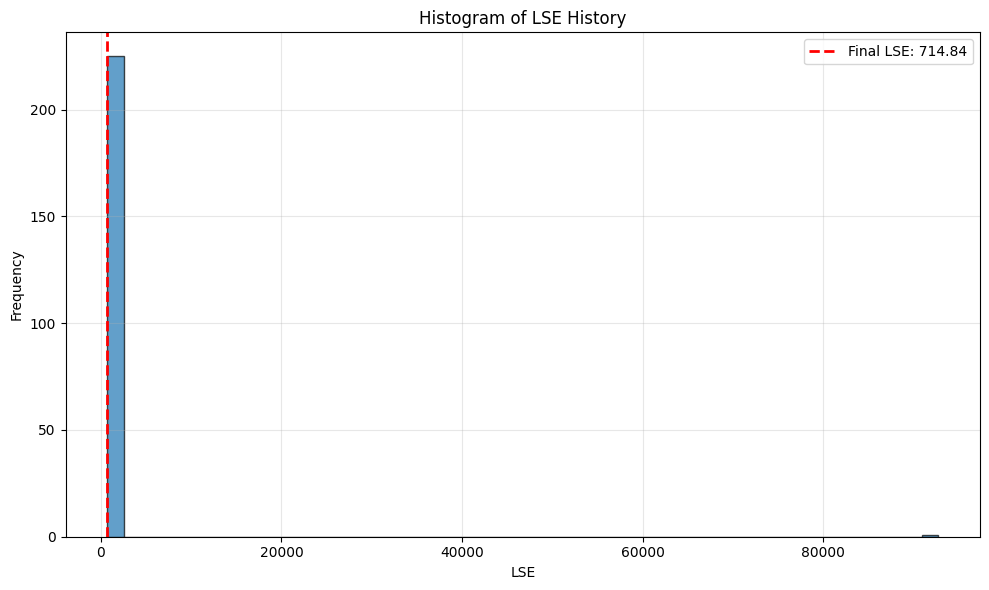


LSE Statistics:
  Initial LSE: 92749.836589
  Final LSE: 714.838346
  Min LSE: 714.838346
  Max LSE: 92749.836589
  Mean LSE: 1185.095432
  Std LSE: 6107.194081


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from EMDPM.visualization import *
from EMDPM.utils import solve_system
from sklearn.decomposition import PCA
from scipy.stats import chi2_contingency, kendalltau
import os

# Load best model from multiple initializations
result_dir = "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/ppmi_multinit_bestparams"
result_path = os.path.join(result_dir, "PPMI_subtyping_multinit_best.npz")

print(f"Loading best model from: {result_path}")
best_data = np.load(result_path, allow_pickle=True)
print(f"Keys: {list(best_data.files)}")

# Extract model information
final_lse = best_data["lse_history"][-1]
print(f"\nBest Model Final LSE: {final_lse:.6f}")
print(f"Number of initializations: {best_data.get('n_initializations', 'N/A')}")
print(f"Best initialization index: {best_data.get('best_init_index', 'N/A')}")
print(f"\nParameters:")
print(f"  lambda_f: {best_data['lambda_f']}")
print(f"  lambda_cog: {best_data['lambda_cog']}")
print(f"  lambda_scalar: {best_data['lambda_scalar']}")
print(f"  lambda_jsd: {best_data['lambda_jsd']}")
print(f"  lambda_beta: {best_data['lambda_beta']}")

# Histogram of LSEs
lse_history = best_data["lse_history"]
plt.figure(figsize=(10, 6))
plt.hist(lse_history, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(final_lse, color='red', linestyle='--', linewidth=2, label=f'Final LSE: {final_lse:.2f}')
plt.xlabel("LSE")
plt.ylabel("Frequency")
plt.title("Histogram of LSE History")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nLSE Statistics:")
print(f"  Initial LSE: {lse_history[0]:.6f}")
print(f"  Final LSE: {lse_history[-1]:.6f}")
print(f"  Min LSE: {np.min(lse_history):.6f}")
print(f"  Max LSE: {np.max(lse_history):.6f}")
print(f"  Mean LSE: {np.mean(lse_history):.6f}")
print(f"  Std LSE: {np.std(lse_history):.6f}")


In [12]:
# Load PPMI data for analysis
df = pd.read_csv("/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv")
df_K = pd.read_csv("/data01/bgutman/LEGACY/Skoltech/datasets/Connectomes/mean_NORM_con_22.csv")

## remove non-longitudinal observations
print("original size:", df.shape)
relevant_cols = [col for col in df.columns if col.startswith(('L_', 'R_')) and ('_thickavg' in col or '_thickavg_resid' in col)]
relevant_cols += ["MCATOT", "TD_score", "PIGD_score"]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=relevant_cols)

subj_counts = df['subj_id'].value_counts()
longitudinal_ids = subj_counts[subj_counts > 1].index
df = df[df['subj_id'].isin(longitudinal_ids)].copy()
df = df.drop_duplicates(subset=["subj_id", "time"])

X_obs = df[[col for col in df.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_obs = X_obs.to_numpy()
X_obs = np.max(X_obs, axis=0) - X_obs

## connectivity matrix to numpy
K = df_K.drop(df_K.columns[0], axis=1).to_numpy()
np.fill_diagonal(K, 0)

# normalization
row_sums = K.sum(axis=1)
median_row_sum = np.median(row_sums)
K = K / median_row_sum

t_max = 40
t_span = np.linspace(0, t_max, int(t_max/0.01))

biomarker_names = [col for col in df.columns 
                   if col.startswith(('L_', 'R_')) and 
                   col.endswith('_thickavg') and 
                   not col.endswith('_thickavg_resid')]

# Extract arrays for analysis
ids_all = df["subj_id"].to_numpy()
dt_all = df["time"].to_numpy()/12  # convert to years
nhy_all = df["NHY"].to_numpy()
cog_all = df[["MCATOT","TD_score","PIGD_score"]].to_numpy()
df["NSD_STAGE"] = df["NSD_STAGE"].replace({"Not NSD": 0, "2b": 2})
df["NSD_STAGE"] = pd.to_numeric(df["NSD_STAGE"], errors='coerce')
nsd = df["NSD_STAGE"].to_numpy()

print(f"Loaded data: {X_obs.shape}, K: {K.shape}, biomarkers: {len(biomarker_names)}")
print(f"Patients: {len(np.unique(ids_all))}, Observations: {len(ids_all)}")


original size: (880, 250)
Loaded data: (504, 68), K: (68, 68), biomarkers: 68
Patients: 146, Observations: 504


In [13]:
# Extract best model assignments and betas
train_ids = best_data["train_ids"]
val_ids = best_data["val_ids"] if "val_ids" in best_data.files else []
beta_train = best_data["beta_history"][:, -1]
beta_val = best_data["beta_val"] if "beta_val" in best_data.files else []

# Combine train and val
all_ids_list = list(train_ids) + list(val_ids)
all_betas_list = list(beta_train) + list(beta_val)
pid_to_beta = {pid: beta for pid, beta in zip(all_ids_list, all_betas_list)}

train_assignments = best_data["train_assignments"]
val_assignments = best_data["val_assignments"] if "val_assignments" in best_data.files else []
all_assignments_list = list(train_assignments) + list(val_assignments)
pid_to_assignment = {pid: assign for pid, assign in zip(all_ids_list, all_assignments_list)}

# Get beta values and assignments aligned with ids_all
beta_all = np.array([pid_to_beta.get(pid, np.nan) for pid in ids_all])
assignment_all = np.array([pid_to_assignment.get(pid, -1) for pid in ids_all])

# Filter to valid patients
valid_mask = np.array([pid in pid_to_beta for pid in ids_all])
ids_valid = ids_all[valid_mask]
beta_valid = beta_all[valid_mask]
assignment_valid = assignment_all[valid_mask]
nhy_valid = nhy_all[valid_mask]
nsd_valid = nsd[valid_mask]
cog_valid = cog_all[valid_mask]

print(f"Valid patients: {len(np.unique(ids_valid))}")
print(f"Subtype 0: {np.sum(assignment_valid == 0)} patients")
print(f"Subtype 1: {np.sum(assignment_valid == 1)} patients")


Valid patients: 146
Subtype 0: 331 patients
Subtype 1: 173 patients


=== Cognitive Regression Parameters ===

Subtype 0:
  Intercept (cog_b): 4.6769
  MCATOT coefficient: 0.1811
  TD_score coefficient: -0.1752
  PIGD_score coefficient: 0.0863

Subtype 1:
  Intercept (cog_b): 38.9639
  MCATOT coefficient: -0.0719
  TD_score coefficient: -0.1573
  PIGD_score coefficient: 0.3857


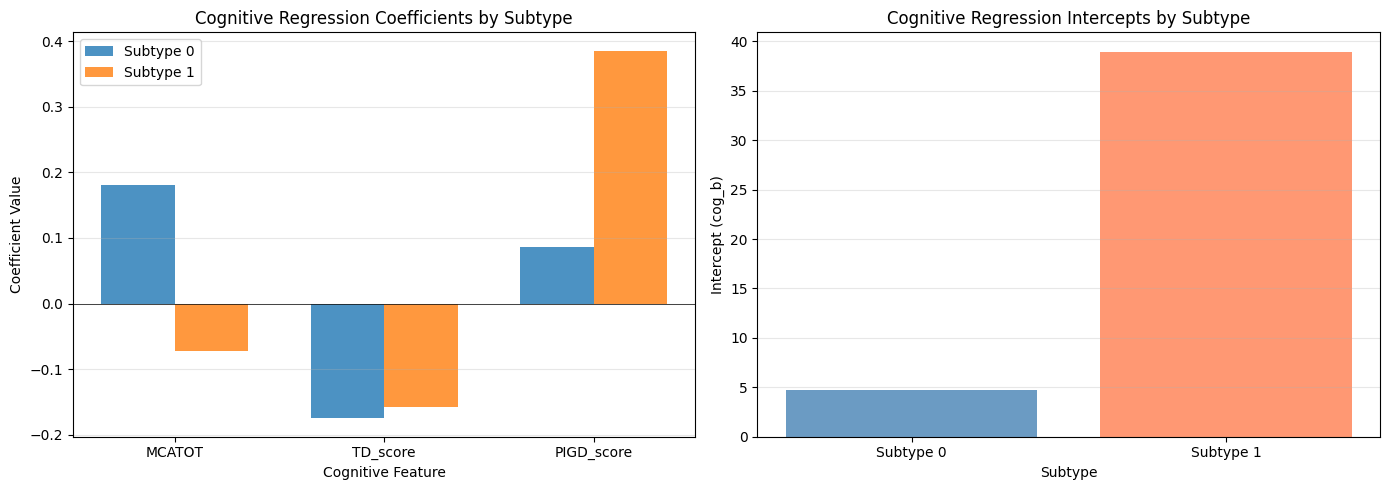


=== Differences Between Subtypes ===
MCATOT: 0.2531 (Subtype 0: 0.1811, Subtype 1: -0.0719)
TD_score: -0.0179 (Subtype 0: -0.1752, Subtype 1: -0.1573)
PIGD_score: -0.2995 (Subtype 0: 0.0863, Subtype 1: 0.3857)
Intercept difference: -34.2870


In [14]:
# Cognitive Parameter Comparison
n_subtypes = 2

cluster_cog_a = best_data["cluster_cog_a"]  # (n_subtypes, n_cog_features)
cluster_cog_b = best_data["cluster_cog_b"]  # (n_subtypes,)

cog_feature_names = ['MCATOT', 'TD_score', 'PIGD_score']

print("=== Cognitive Regression Parameters ===")
for subtype in range(n_subtypes):
    print(f"\nSubtype {subtype}:")
    print(f"  Intercept (cog_b): {cluster_cog_b[subtype]:.4f}")
    for i, name in enumerate(cog_feature_names):
        print(f"  {name} coefficient: {cluster_cog_a[subtype, i]:.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Coefficients comparison
x = np.arange(len(cog_feature_names))
width = 0.35
axes[0].bar(x - width/2, cluster_cog_a[0], width, label='Subtype 0', alpha=0.8)
axes[0].bar(x + width/2, cluster_cog_a[1], width, label='Subtype 1', alpha=0.8)
axes[0].set_xlabel('Cognitive Feature')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Cognitive Regression Coefficients by Subtype')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cog_feature_names)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Plot 2: Intercepts comparison
axes[1].bar([0, 1], cluster_cog_b, alpha=0.8, color=['steelblue', 'coral'])
axes[1].set_xlabel('Subtype')
axes[1].set_ylabel('Intercept (cog_b)')
axes[1].set_title('Cognitive Regression Intercepts by Subtype')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Subtype 0', 'Subtype 1'])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Calculate differences
print("\n=== Differences Between Subtypes ===")
for i, name in enumerate(cog_feature_names):
    diff = cluster_cog_a[0, i] - cluster_cog_a[1, i]
    print(f"{name}: {diff:.4f} (Subtype 0: {cluster_cog_a[0, i]:.4f}, Subtype 1: {cluster_cog_a[1, i]:.4f})")
print(f"Intercept difference: {cluster_cog_b[0] - cluster_cog_b[1]:.4f}")


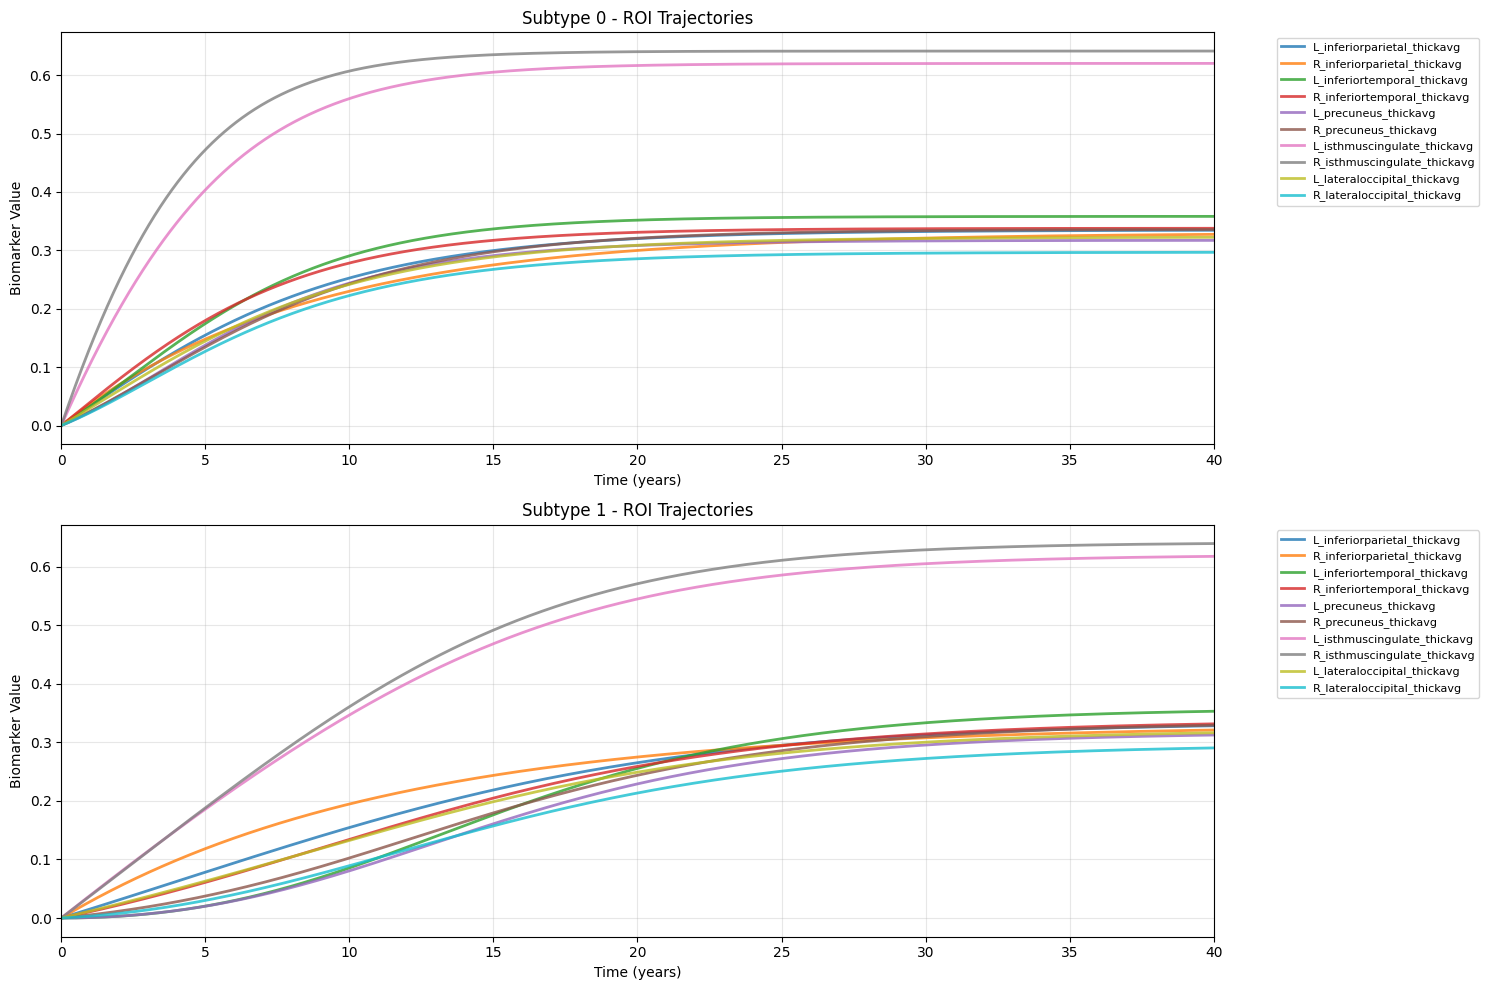

In [15]:
# ROI Subplots: 10 ROI trajectories for each subtype
ROI = [6, 40, 7, 41, 23, 57, 8, 42, 9, 43]
ROI_names = [biomarker_names[i] for i in ROI]

# Extract cluster parameters
cluster_f = best_data["cluster_f"]  # (n_subtypes, n_biomarkers)
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

final_scalar_K = best_data["final_scalar_K"]
final_s = best_data["final_s"]

# Plot trajectories for each subtype
fig, axes = plt.subplots(n_subtypes, 1, figsize=(15, 5*n_subtypes))
if n_subtypes == 1:
    axes = [axes]

for subtype in range(n_subtypes):
    f_subtype = cluster_f[subtype]
    x0 = np.zeros(n_biomarkers)
    Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K) * final_s[:, None]
    
    ax = axes[subtype]
    for i, roi_idx in enumerate(ROI):
        ax.plot(t_span, Xtraj_subtype[roi_idx], label=ROI_names[i], linewidth=2, alpha=0.8)
    
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Biomarker Value")
    ax.set_title(f"Subtype {subtype} - ROI Trajectories")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)

plt.tight_layout()
plt.show()



All subgroup types found: ['GBA' 'LRRK2' 'PRKN' 'Sporadic PD']

=== Contingency Table: Discovered Subtypes vs All Clinical Subgroups ===
Clinical Subgroup   GBA  LRRK2  PRKN  Sporadic PD
Discovered Subtype                               
0                     3      1     3           88
1                     3      0     2           46

Chi-square test:
  χ² = 1.2142
  p-value = 0.7496
  df = 3


<Figure size 1200x600 with 0 Axes>

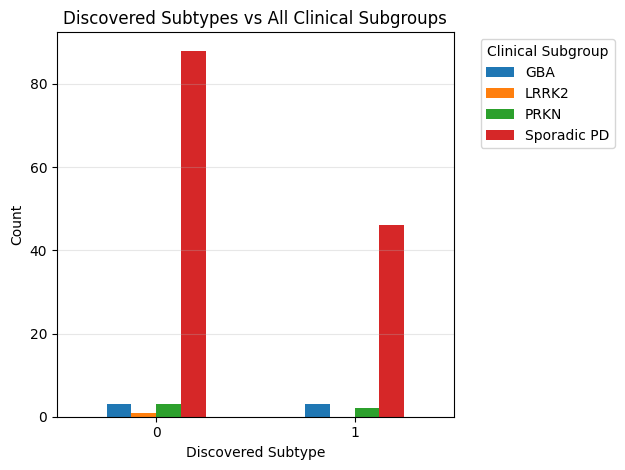


=== Contingency Table: Discovered Subtypes vs Binary Clinical Subgroups ===
Clinical Subgroup   Non-Sporadic PD  Sporadic PD
Discovered Subtype                              
0                                 7           88
1                                 5           46

Chi-square test (binary):
  χ² = 0.0379
  p-value = 0.8455
  df = 1


<Figure size 1000x600 with 0 Axes>

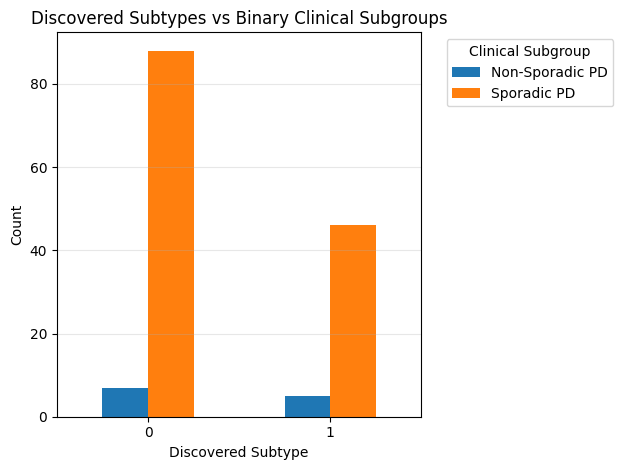

In [16]:
# Clinical Subgroup Comparison: All Subgroup Types
# Get unique patient IDs and their subgroup assignments
unique_pids = np.unique(ids_valid)
pid_to_subgroup = {}
for pid in unique_pids:
    mask = df['subj_id'] == pid
    if mask.sum() > 0:
        subgroups = df.loc[mask, 'subgroup'].dropna().unique()
        if len(subgroups) > 0:
            # Take most common subgroup if multiple
            pid_to_subgroup[pid] = subgroups[0] if len(subgroups) == 1 else df.loc[mask, 'subgroup'].mode()[0]

# Map to our assignments
subgroup_per_patient = np.array([pid_to_subgroup.get(pid, 'Unknown') for pid in unique_pids])
assignment_per_patient = np.array([pid_to_assignment.get(pid, -1) for pid in unique_pids])

# Get all unique subgroup types
all_subgroups = np.unique(subgroup_per_patient)
print(f"\nAll subgroup types found: {all_subgroups}")

# Create contingency table with all subgroup types
contingency_all = pd.crosstab(
    pd.Series(assignment_per_patient, name='Discovered Subtype'),
    pd.Series(subgroup_per_patient, name='Clinical Subgroup')
)
print("\n=== Contingency Table: Discovered Subtypes vs All Clinical Subgroups ===")
print(contingency_all)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_all)
print(f"\nChi-square test:")
print(f"  χ² = {chi2:.4f}")
print(f"  p-value = {p_value:.4f}")
print(f"  df = {dof}")

# Plot all subgroups
plt.figure(figsize=(12, 6))
contingency_all.plot(kind='bar', stacked=False)
plt.title('Discovered Subtypes vs All Clinical Subgroups')
plt.xlabel('Discovered Subtype')
plt.ylabel('Count')
plt.legend(title='Clinical Subgroup', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Also create binary classification: Sporadic PD vs Non-Sporadic PD
sporadic_mask = np.array([sg == 'Sporadic PD' if isinstance(sg, str) else False for sg in subgroup_per_patient])
clinical_subgroup_binary = np.where(sporadic_mask, 'Sporadic PD', 'Non-Sporadic PD')

# Create contingency table for binary
contingency_binary = pd.crosstab(
    pd.Series(assignment_per_patient, name='Discovered Subtype'),
    pd.Series(clinical_subgroup_binary, name='Clinical Subgroup')
)
print("\n=== Contingency Table: Discovered Subtypes vs Binary Clinical Subgroups ===")
print(contingency_binary)

# Chi-square test for binary
chi2_binary, p_value_binary, dof_binary, expected_binary = chi2_contingency(contingency_binary)
print(f"\nChi-square test (binary):")
print(f"  χ² = {chi2_binary:.4f}")
print(f"  p-value = {p_value_binary:.4f}")
print(f"  df = {dof_binary}")

# Plot binary
plt.figure(figsize=(10, 6))
contingency_binary.plot(kind='bar', stacked=False)
plt.title('Discovered Subtypes vs Binary Clinical Subgroups')
plt.xlabel('Discovered Subtype')
plt.ylabel('Count')
plt.legend(title='Clinical Subgroup', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



Subtype 0 Beta Statistics:
  Mean: 7.5598
  Median: 7.6018
  Std: 0.9474
  Min: 5.5503
  Max: 9.8094



Subtype 1 Beta Statistics:
  Mean: 35.4452
  Median: 35.2672
  Std: 1.2267
  Min: 33.2241
  Max: 38.1491


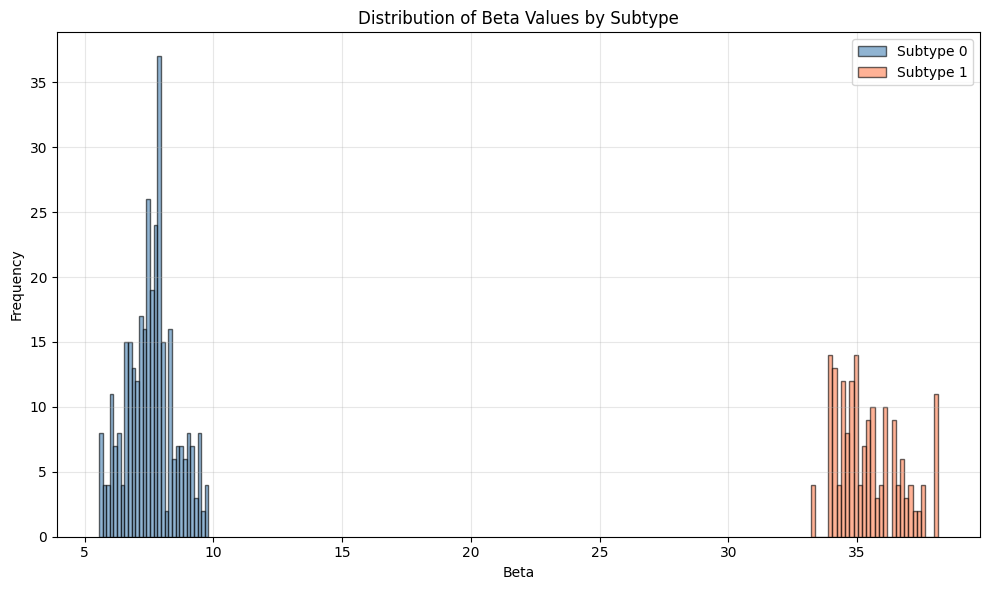

In [17]:
# Beta distributions by subtype
plt.figure(figsize=(10, 6))
colors = ['steelblue', 'coral']
for subtype in range(n_subtypes):
    beta_subtype = beta_valid[assignment_valid == subtype]
    plt.hist(beta_subtype, bins=30, alpha=0.6, label=f'Subtype {subtype}', 
             color=colors[subtype], edgecolor='black')
    print(f"\nSubtype {subtype} Beta Statistics:")
    print(f"  Mean: {np.mean(beta_subtype):.4f}")
    print(f"  Median: {np.median(beta_subtype):.4f}")
    print(f"  Std: {np.std(beta_subtype):.4f}")
    print(f"  Min: {np.min(beta_subtype):.4f}")
    print(f"  Max: {np.max(beta_subtype):.4f}")

plt.xlabel("Beta")
plt.ylabel("Frequency")
plt.title("Distribution of Beta Values by Subtype")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/home/dsemchin/Progression_models_simulations/EMDPM/visualization.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1500x700 with 0 Axes>

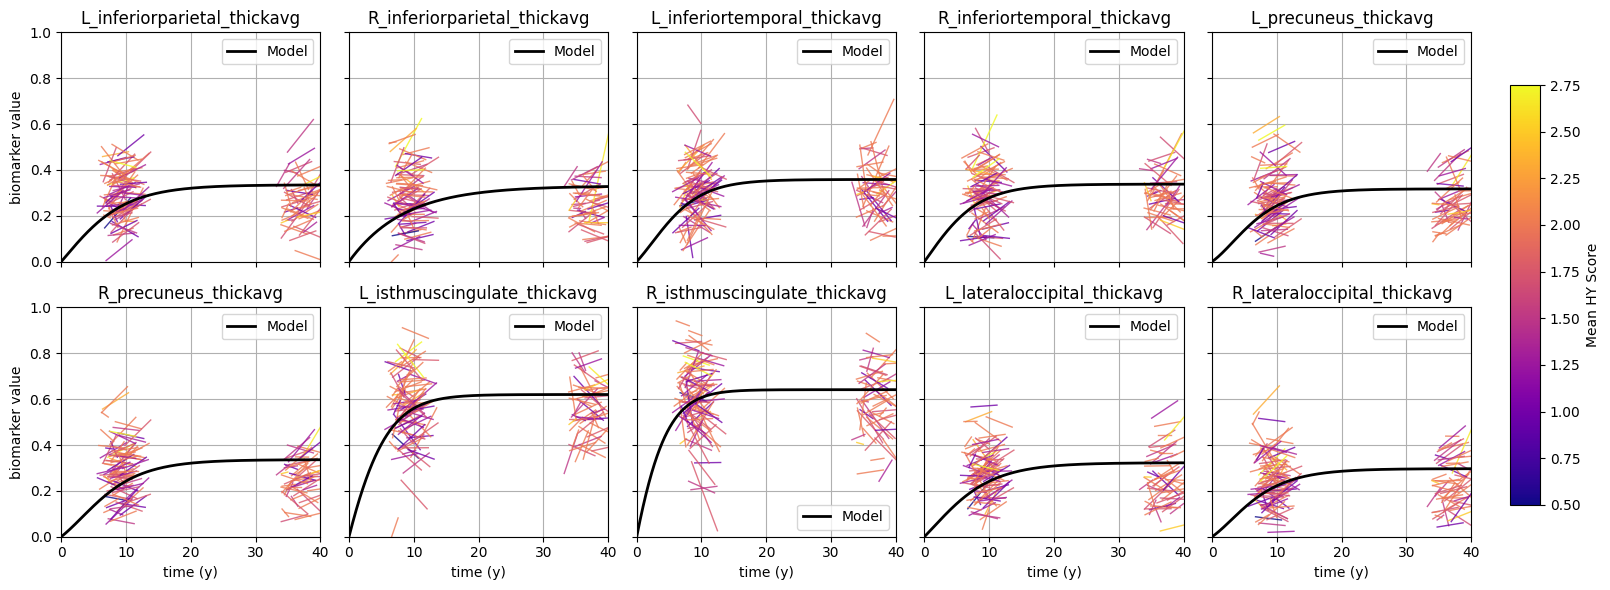

<Figure size 640x480 with 0 Axes>

In [18]:
# Spaghetti plots for ROI regions - NHY colored
from sklearn.linear_model import LinearRegression
import matplotlib.cm as cm
import matplotlib.colors as colors

biomarker_names = [col for col in df.columns 
                   if col.startswith(('L_', 'R_')) and 
                   col.endswith('_thickavg') and 
                   not col.endswith('_thickavg_resid')]

ROI = [6, 40, 7, 41, 23, 57, 8, 42, 9, 43]
ROI_names = [biomarker_names[i] for i in ROI]

# Get model trajectory for best model (using subtype 0 as representative)
f_subtype0 = cluster_f[0]
x0 = np.zeros(n_biomarkers)
Xtraj_best = solve_system(x0, f_subtype0, K, t_span, final_scalar_K) * final_s[:, None]

# Filter to valid patients
valid_patients_mask = np.array([pid in pid_to_beta for pid in ids_all])
ids_best = ids_all[valid_patients_mask]
dt_best = dt_all[valid_patients_mask]
X_obs_best = X_obs[valid_patients_mask]
nhy_best = nhy_all[valid_patients_mask]
nsd_best = nsd[valid_patients_mask]
beta_best = beta_all[valid_patients_mask]

# Create pid_to_index mapping
unique_ids_best = np.unique(ids_best)
pid_to_index = {pid: idx for idx, pid in enumerate(unique_ids_best)}

plt.figure(figsize=(15, 7))
plot_all_patient_regression_lines_grid_nhy(
    X=X_obs_best,
    dt=dt_best,
    ids=ids_best,
    beta=beta_best,
    t_span=t_span,
    nhy=nhy_best,
    model=Xtraj_best,
    biomarker_indices=ROI,
    biomarker_labels=biomarker_names,
    max_lines=500,
    t_max=t_span[-1]
)
plt.suptitle(f"Best Model (LSE={final_lse:.3f}) - NHY Colored Spaghetti Plot - ROI Regions", y=1.02)
plt.show()


/tmp/ipykernel_3907/3260730660.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1500x700 with 0 Axes>

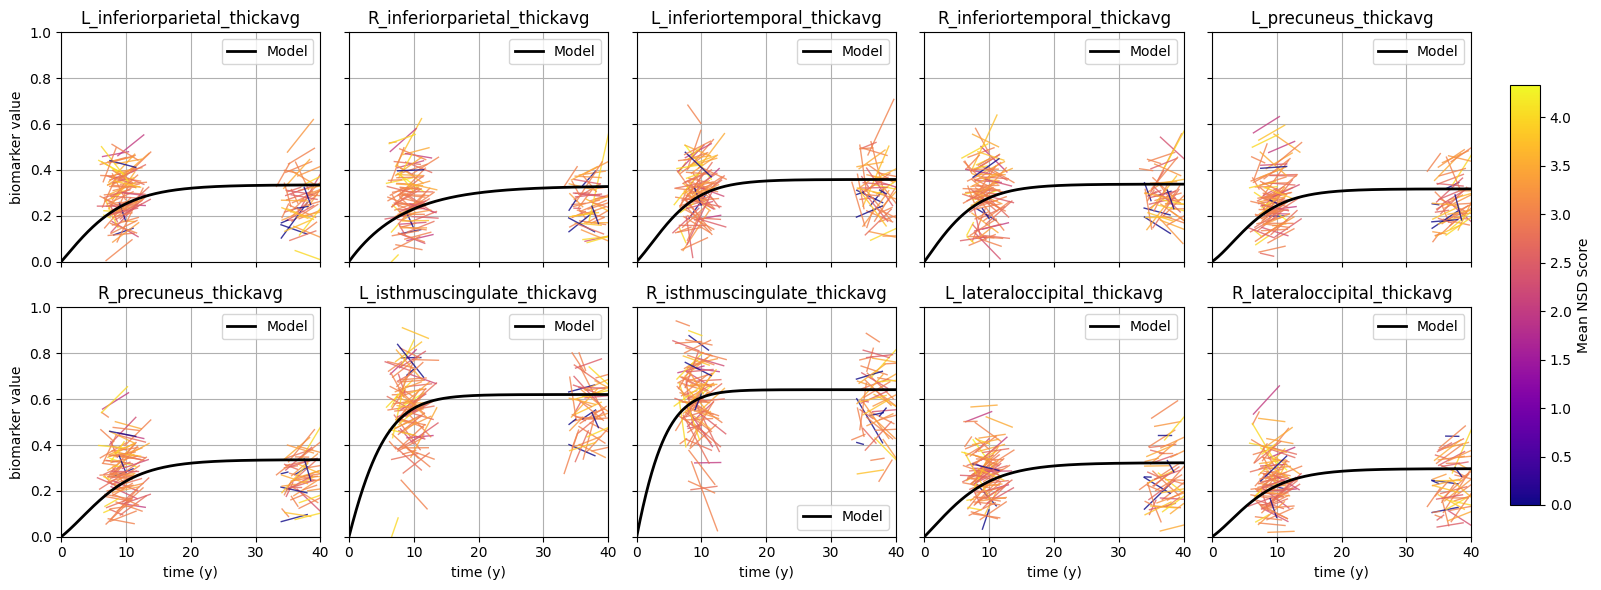

<Figure size 640x480 with 0 Axes>

In [19]:
# Spaghetti plots for ROI regions - NSD colored
def plot_all_patient_regression_lines_grid_nsd(X, dt, ids, beta, t_span, nsd, model=None,
                                               biomarker_indices=None, biomarker_labels=None,
                                               max_lines=500, t_max=40):
    """Plot regression lines per patient colored by mean NSD score."""
    if biomarker_indices is None:
        biomarker_indices = list(range(X.shape[1]))

    unique_ids = np.unique(ids)
    pid_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}

    # compute mean NSD score per patient
    mean_nsd = {}
    for pid in unique_ids:
        nsd_i = nsd[ids == pid]
        valid_nsd = nsd_i[~np.isnan(nsd_i)]
        mean_nsd[pid] = np.mean(valid_nsd) if len(valid_nsd) > 0 else np.nan

    # colormap setup
    cmap = cm.plasma
    nsd_vals = np.array([v for v in mean_nsd.values() if not np.isnan(v)])
    if len(nsd_vals) > 0:
        norm = colors.Normalize(vmin=np.nanmin(nsd_vals), vmax=np.nanmax(nsd_vals))
    else:
        norm = colors.Normalize(vmin=0, vmax=1)

    n_plots = len(biomarker_indices)
    n_cols = 5
    n_rows = 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows), squeeze=True)
    axes = axes.flatten()

    for plot_idx, j in enumerate(biomarker_indices):
        ax = axes[plot_idx]
        title = biomarker_labels[j] if biomarker_labels else f"biomarker {j}"
        ax.set_title(f"{title}")
        
        line_count = 0
        for pid in unique_ids:
            if line_count >= max_lines:
                break
            mask = (ids == pid)
            if np.sum(mask) < 2:
                continue

            X_i = X[mask, j]
            dt_i = dt[mask]
            beta_i = beta[pid_to_index[pid]]
            t_ij = dt_i + beta_i

            nsd_mean = mean_nsd[pid]
            if np.isnan(nsd_mean):
                continue
            line_color = cmap(norm(nsd_mean))

            model_i = LinearRegression().fit(t_ij.reshape(-1, 1), X_i)
            t_fit = np.linspace(t_ij.min(), t_ij.max(), 20)
            x_fit = model_i.predict(t_fit.reshape(-1, 1))

            ax.plot(t_fit, x_fit, color=line_color, alpha=0.8, linewidth=1)
            line_count += 1

        # plot model-predicted trajectory
        if model is not None:
            ax.plot(t_span, model[j], color='black', linewidth=2, label="Model")
            ax.legend()
            
        # determine subplot grid position
        row_idx = plot_idx // n_cols
        col_idx = plot_idx % n_cols

        # only show x-labels on bottom row
        if row_idx == n_rows - 1:
            ax.set_xlabel("time (y)")
        else:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)

        # only show y-labels on leftmost column
        if col_idx == 0:
            ax.set_ylabel("biomarker value")
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

        ax.set_ylim(0, 1)
        ax.grid(True)
        ax.set_xlim(0, t_max)

    # remove unused axes
    for k in range(n_plots, len(axes)):
        fig.delaxes(axes[k])

    # Add colorbar for NSD scale
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([1.01, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Mean NSD Score")
    
    plt.tight_layout()
    plt.show()

# Plot NSD spaghetti plot
plt.figure(figsize=(15, 7))
plot_all_patient_regression_lines_grid_nsd(
    X=X_obs_best,
    dt=dt_best,
    ids=ids_best,
    beta=beta_best,
    t_span=t_span,
    nsd=nsd_best,
    model=Xtraj_best,
    biomarker_indices=ROI,
    biomarker_labels=biomarker_names,
    max_lines=500,
    t_max=t_span[-1]
)
plt.suptitle(f"Best Model (LSE={final_lse:.3f}) - NSD Colored Spaghetti Plot - ROI Regions", y=1.02)
plt.show()
